# Quantum vs Classical Portfolio Optimisation

**Business process:** monthly tactical asset allocation across an 8-ETF universe (US / international / EM equity, Treasuries, IG credit, gold, commodities).

Every rebalance we choose **exactly 4 of the 8 assets** to hold equal-weighted for the next period. Two engines make that choice:

| Engine | How it decides |
|---|---|
| **Quantum (QAOA)** | Solves a mean-variance **QUBO** ( minimise `q xᵀΣx − μᵀx`, `Σxᵢ = 4` ) on a state-vector simulator |
| **Classical ML** | A **Random Forest** predicts each asset's next-month return; we hold the top 4 |

Both are run through the **same** walk-forward backtest and compared against a static 60/40 and an equal-weight benchmark.

## How to run
1. Activate the environment: `conda activate qml-classiq` (or `pip install -r requirements.txt`).
2. Select the **qml-classiq** kernel (top-right).
3. Run all cells top-to-bottom. Price data is downloaded once and cached to `data/`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import portfolio_utils as pu
import quantum_portfolio_qaoa as quantum
import classical_portfolio_ml as classical

warnings.filterwarnings("ignore")

monthly_returns = pu.download_monthly_returns()
print(f"Loaded {monthly_returns.shape[0]} months x {monthly_returns.shape[1]} assets")
monthly_returns.tail()

Loaded 119 months x 8 assets


,SPY,QQQ,EFA,EEM,TLT,LQD,GLD,DBC
Date,,,,,,,,
2024-08-31,0.023366,0.011039,0.032603,0.009779,0.021112,0.018705,0.020922,-0.020815
2024-09-30,0.021004,0.026216,0.007833,0.057413,0.019995,0.019629,0.050889,0.007237
2024-10-31,-0.008924,-0.008646,-0.052732,-0.030746,-0.054549,-0.031794,0.042993,0.014369
2024-11-30,0.059634,0.053508,-0.003156,-0.026772,0.019872,0.017909,-0.031241,-0.019920
2024-12-31,-0.020497,0.013147,-0.029502,-0.013676,-0.058772,-0.024298,-0.020196,0.011994


## 1. Quantum engine - QAOA mean-variance QUBO

At each rebalance a fresh 8-qubit QUBO is solved with QAOA. The **same** problem is also solved exactly (NumPy eigensolver) at every rebalance, so the diagnostics report how often QAOA reaches the true optimum (`match_rate`) and the average objective shortfall (`mean_optimality_gap` = 0.0 means QAOA found the optimum every time).

In [2]:
quantum_result = quantum.run_quantum_backtest(monthly_returns, verbose=True)
quantum_returns = quantum_result["strategy_returns"]

print("\nQuantum circuit diagnostics:")
for k, v in quantum_result["diagnostics"].items():
    print(f"  {k}: {v}")

2018-02-28  ==  ['SPY', 'QQQ', 'EEM', 'LQD']


2018-05-31  ==  ['SPY', 'QQQ', 'LQD', 'GLD']


2018-08-31  ==  ['SPY', 'QQQ', 'LQD', 'GLD']


2018-11-30  ==  ['SPY', 'QQQ', 'GLD', 'DBC']


2019-02-28  ==  ['SPY', 'QQQ', 'EEM', 'GLD']


...

2024-02-29  ==  ['SPY', 'QQQ', 'GLD', 'DBC']


2024-05-31  ==  ['SPY', 'QQQ', 'GLD', 'DBC']


2024-08-31  ==  ['SPY', 'QQQ', 'GLD', 'DBC']


2024-11-30  ==  ['SPY', 'QQQ', 'GLD', 'DBC']



Quantum circuit diagnostics:
  n_qubits: 8
  circuit_depth: 4
  qaoa_reps: 1
  cobyla_maxiter: 80
  shots: 1024
  risk_aversion: 1.0
  n_rebalances: 28
  match_rate: 1.0
  mean_optimality_gap: 0.0
  total_qaoa_seconds: 188.6976017000561


## 2. Classical challenger - Random Forest return predictor

The same 'hold 4 of 8, equal-weighted' rule, but the four assets are chosen by a Random Forest trained on momentum / volatility features.

In [3]:
classical_result = classical.run_classical_ml_backtest(monthly_returns, verbose=True)
classical_returns = classical_result["strategy_returns"]

print("\nML model diagnostics:")
for k, v in classical_result["diagnostics"].items():
    print(f"  {k}: {v}")

2018-02-28  ->  ['QQQ', 'EEM', 'GLD', 'LQD']
2018-05-31  ->  ['DBC', 'TLT', 'LQD', 'QQQ']


2018-08-31  ->  ['GLD', 'SPY', 'DBC', 'TLT']
2018-11-30  ->  ['EEM', 'EFA', 'QQQ', 'SPY']


2019-02-28  ->  ['EEM', 'EFA', 'DBC', 'QQQ']
2019-05-31  ->  ['QQQ', 'SPY', 'LQD', 'EEM']


2019-08-31  ->  ['DBC', 'SPY', 'QQQ', 'GLD']
2019-11-30  ->  ['EEM', 'LQD', 'TLT', 'DBC']


2020-02-29  ->  ['LQD', 'SPY', 'DBC', 'EFA']
2020-05-31  ->  ['DBC', 'SPY', 'EEM', 'QQQ']


...

2022-08-31  ->  ['QQQ', 'DBC', 'EFA', 'SPY']
2022-11-30  ->  ['EEM', 'QQQ', 'EFA', 'SPY']


2023-02-28  ->  ['EFA', 'TLT', 'EEM', 'GLD']
2023-05-31  ->  ['QQQ', 'TLT', 'EFA', 'EEM']


2023-08-31  ->  ['EEM', 'DBC', 'EFA', 'QQQ']
2023-11-30  ->  ['QQQ', 'SPY', 'GLD', 'EEM']


2024-02-29  ->  ['QQQ', 'SPY', 'TLT', 'EEM']
2024-05-31  ->  ['QQQ', 'SPY', 'EFA', 'DBC']


2024-08-31  ->  ['EFA', 'TLT', 'EEM', 'SPY']
2024-11-30  ->  ['SPY', 'QQQ', 'GLD', 'TLT']

ML model diagnostics:
  model: RandomForestRegressor(n=200, depth=4)
  features: ['r_lag1', 'r_lag2', 'r_lag3', 'mom_3', 'mom_6', 'mom_12', 'vol_6']
  prediction_rmse: 0.05108700071955339
  directional_accuracy: 0.5535714285714286
  n_predictions: 224


## 3. Benchmarks

Static 60/40 (60% SPY, 40% TLT) and an equal-weight-everything portfolio, aligned to the same dates.

In [4]:
assets = list(monthly_returns.columns)
dates = quantum_returns.index
aligned = monthly_returns.loc[dates]

benchmark_6040 = pd.Series(aligned.values @ pu.benchmark_60_40(assets),
                           index=dates, name="Static 60/40")
benchmark_eqw = pd.Series(aligned.values @ pu.benchmark_equal_weight(assets),
                          index=dates, name="Equal Weight")

strategies = {
    "QAOA Quantum": quantum_returns,
    "Classical ML": classical_returns,
    "Static 60/40": benchmark_6040,
    "Equal Weight": benchmark_eqw,
}

## 4. Performance comparison

In [5]:
performance = pu.summarise_performance(strategies)
performance.round(4)

,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio
QAOA Quantum,0.0979,0.1126,0.6914,-0.2051,0.4771
Classical ML,0.0854,0.1416,0.4621,-0.1765,0.4840
Static 60/40,0.0874,0.1293,0.5208,-0.2621,0.3333
Equal Weight,0.0787,0.1148,0.5108,-0.2026,0.3883


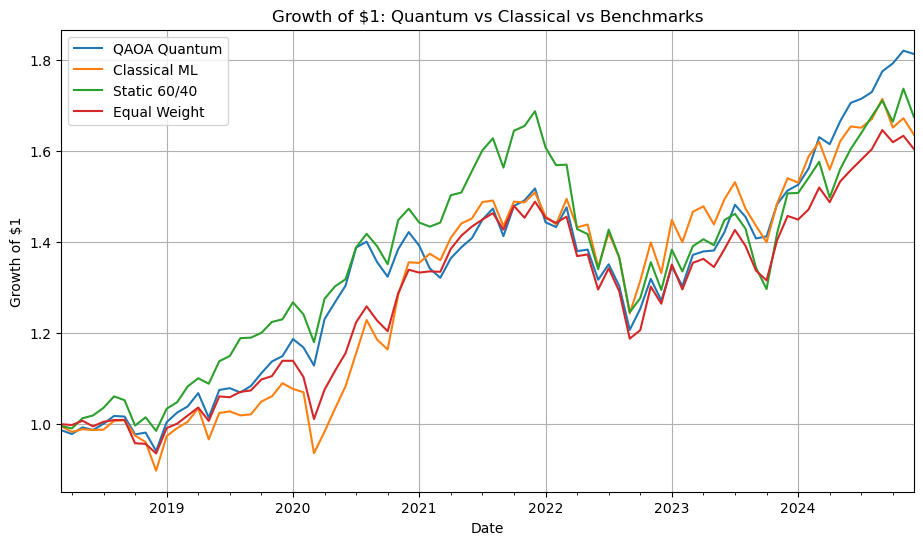

In [6]:
plt.figure(figsize=(11, 6))
for name, r in strategies.items():
    (1 + r).cumprod().plot(label=name)
plt.title("Growth of $1: Quantum vs Classical vs Benchmarks")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

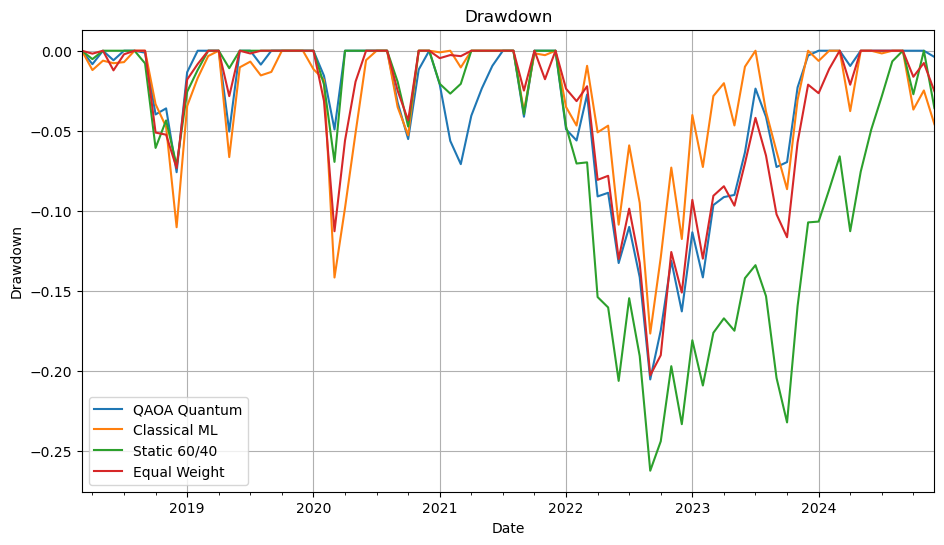

In [7]:
plt.figure(figsize=(11, 6))
for name, r in strategies.items():
    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    drawdown.plot(label=name)
plt.title("Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

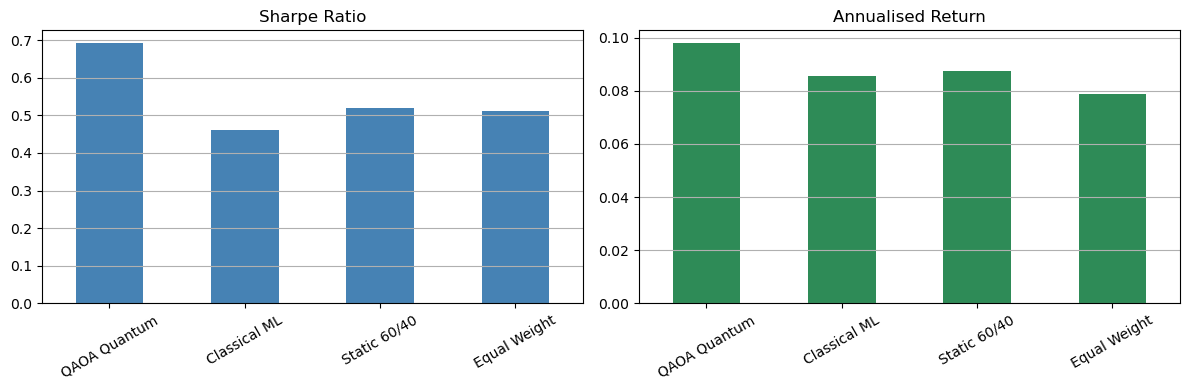

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
performance["Sharpe Ratio"].plot(kind="bar", ax=axes[0], title="Sharpe Ratio", color="steelblue")
performance["Annualised Return"].plot(kind="bar", ax=axes[1], title="Annualised Return", color="seagreen")
for ax in axes:
    ax.grid(True, axis="y")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 5. What did each engine choose?

How often each asset was held over the backtest - a window into the different 'personalities' of the quantum optimiser and the ML predictor.

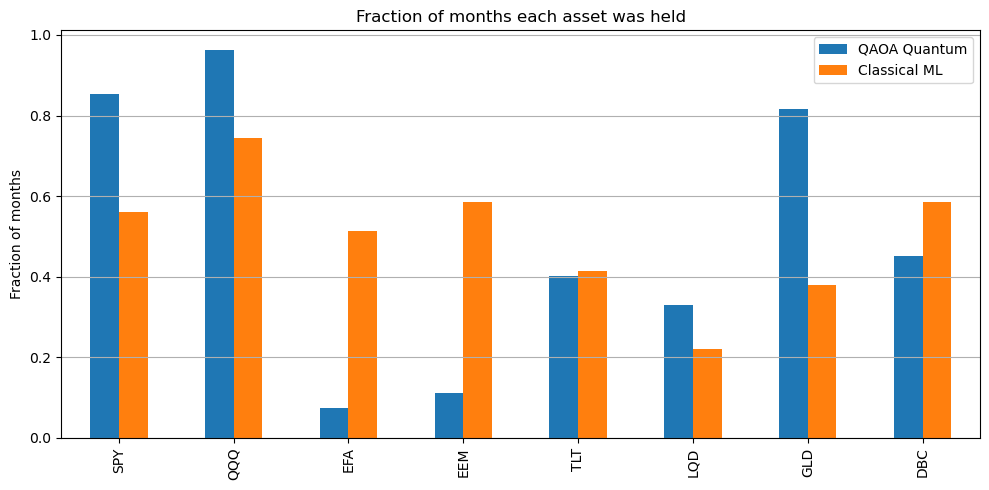

In [9]:
def selection_frequency(selections):
    counts = {a: 0 for a in assets}
    for sel in selections:
        for a in sel:
            counts[a] += 1
    return pd.Series(counts) / len(selections)

frequency = pd.DataFrame({
    "QAOA Quantum": selection_frequency(quantum_result["selections"]),
    "Classical ML": selection_frequency(classical_result["selections"]),
})
frequency.plot(kind="bar", figsize=(10, 5), title="Fraction of months each asset was held")
plt.ylabel("Fraction of months")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 6. Quantum vs classical - side-by-side diagnostics

In [10]:
print("Quantum (QAOA) diagnostics")
for k, v in quantum_result["diagnostics"].items():
    print(f"  {k}: {v}")

print("\nClassical (Random Forest) diagnostics")
for k, v in classical_result["diagnostics"].items():
    print(f"  {k}: {v}")

Quantum (QAOA) diagnostics
  n_qubits: 8
  circuit_depth: 4
  qaoa_reps: 1
  cobyla_maxiter: 80
  shots: 1024
  risk_aversion: 1.0
  n_rebalances: 28
  match_rate: 1.0
  mean_optimality_gap: 0.0
  total_qaoa_seconds: 188.6976017000561

Classical (Random Forest) diagnostics
  model: RandomForestRegressor(n=200, depth=4)
  features: ['r_lag1', 'r_lag2', 'r_lag3', 'mom_3', 'mom_6', 'mom_12', 'vol_6']
  prediction_rmse: 0.05108700071955339
  directional_accuracy: 0.5535714285714286
  n_predictions: 224


## 7. Read-out

- **Solution quality:** at every rebalance the 8-qubit QAOA circuit reproduces the *exact* optimal asset subset (`match_rate = 1.0`, `mean_optimality_gap = 0.0`) — the circuit design is fully validated against the classical optimum.
- **Headline result:** the quantum-selected portfolio earns the **best risk-adjusted return** (Sharpe ≈ 0.69), ahead of the classical ML challenger (≈ 0.46) and both passive benchmarks (≈ 0.51–0.52).
- The performance table and growth chart show how the **quantum-selected** portfolio stacks up against the **ML-selected** portfolio and the passive benchmarks (Sharpe ratio is the key risk-adjusted number).
- For a real deployment the quantum advantage appears as the universe grows: choosing B of N assets is `C(N, B)`, which explodes classically but maps onto a linear number of qubits.

*(See the Word technical specification for the hardware, error-correction and commercial cost/benefit discussion.)*